In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy import interpolate

In [9]:
colors=plt.rcParams['axes.prop_cycle'].by_key()['color']

In [10]:

paletteFessa = [
    '#1F3B73', # dark-blue
    '#2F9294', # green-blue
    '#50B28D', # green
    '#A7D655', # pisello
    '#FFE03E', # yellow
    '#FFA955', # orange
    '#F4173B', #'#D6573B', # red
]

paletteCaCO3 = [
    '#A7D655',
    '#909090',
    '#F4173B',
    '#1F3B73',
]

In [11]:
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 20
plt.rc('text', usetex=False)
plt.rcParams['figure.figsize'] = (3*3.5, 3*2.5) # The unit here is inches. 3.5 is good for one column, 7 is good for whole page

In [12]:

binNumber=300

/tmp/ipykernel_1332472/3893014260.py:26: RuntimeWarning: divide by zero encountered in log
  fes = -(1/beta)*np.log(Z)


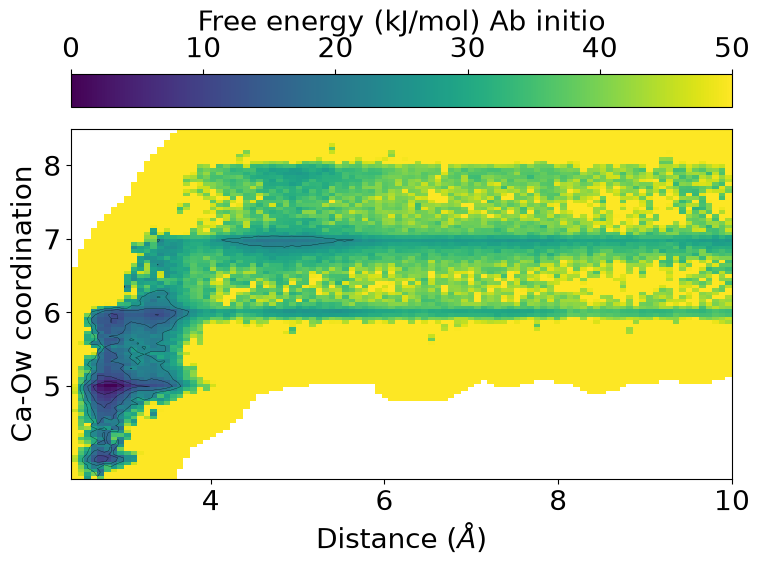

/tmp/ipykernel_1332472/3893014260.py:52: RuntimeWarning: divide by zero encountered in log
  fes_bias=-(1/beta)*np.log(histo)
/tmp/ipykernel_1332472/3893014260.py:54: RuntimeWarning: divide by zero encountered in log
  fes_renorm = -(1/beta)*np.log(histo/factor)


0.2816666666666667


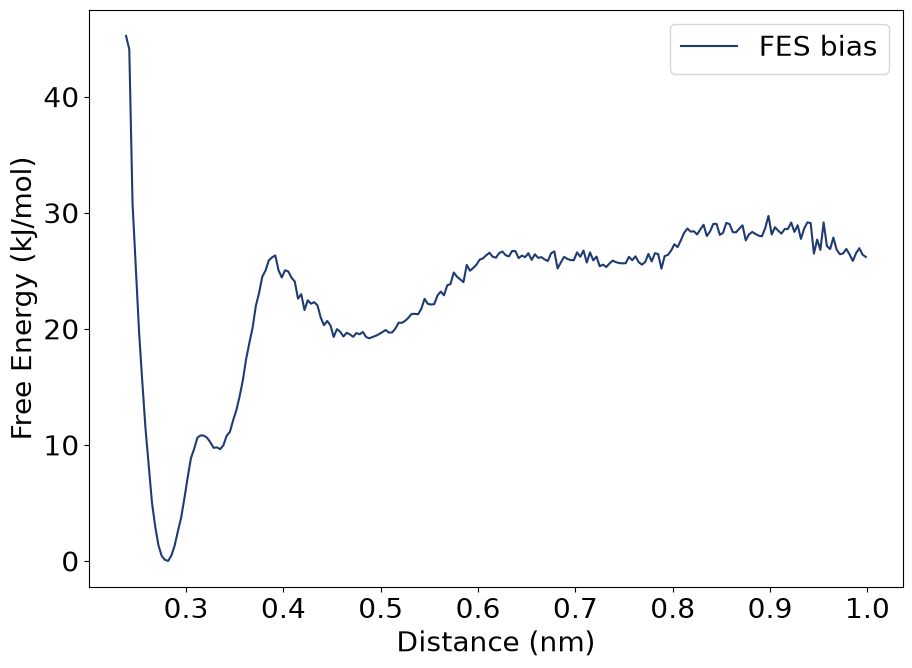

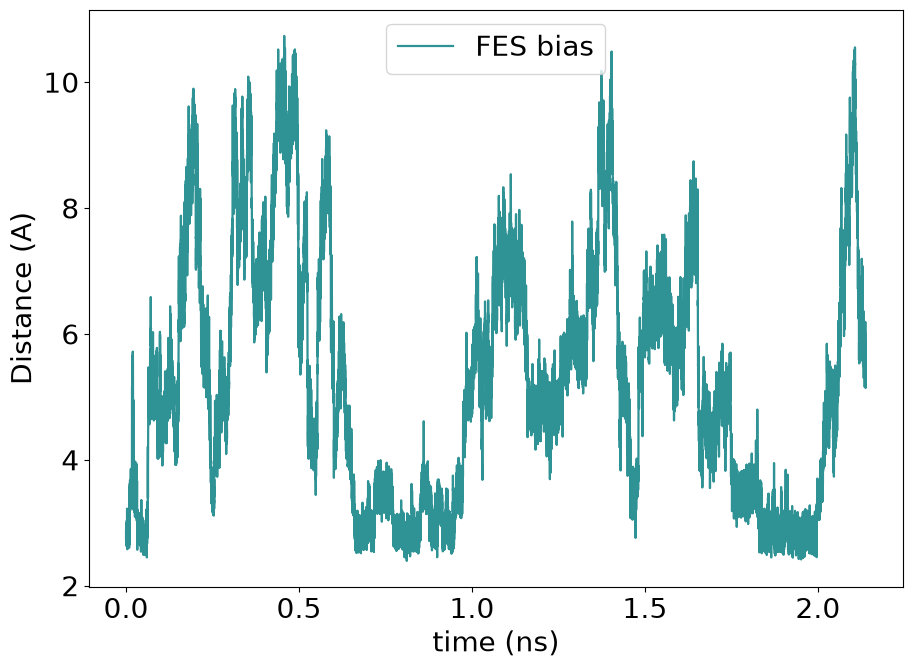

In [14]:
Nignore=0
colvar=np.genfromtxt("./COLVAR")
cv1=10*colvar[Nignore:,1]
time=colvar[Nignore:,0]
bias=colvar[Nignore:,2]+colvar[Nignore:,7]
cv2=colvar[Nignore:,10]

kb=0.00831446261
temp=330
beta=1/(kb*temp)
logweights=beta*bias
logweights -= np.amax(logweights)

xmin=np.amin(cv1)
xmax=10. 
ymin=np.amin(cv2)
ymax=np.amax(cv2)
X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([cv1, cv2])

kernel = stats.gaussian_kde(values, weights=np.exp(logweights), bw_method=0.07)
Z = np.reshape(kernel(positions).T, X.shape)


fes = -(1/beta)*np.log(Z)
fes -= np.amin(fes)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

im = ax.imshow(np.rot90(fes), extent=[xmin, xmax, ymin, ymax], vmin=0, vmax=50, aspect='auto')

cbar = fig.colorbar(im, orientation="horizontal", ax=ax, location='top')
cs = ax.contour(X, Y, fes, levels=np.linspace(0,24,5), colors='k', vmin=0, vmax=30, linewidths=0.2)

cbar.set_label('Free energy (kJ/mol) Ab initio')

ax.set_xlim([xmin, xmax])
ax.set_ylim([np.amin(cv2), 8.5])
ax.set_yticks([5, 6, 7, 8])

ax.set_xlabel(r"Distance ($\AA$)")
ax.set_ylabel(r"Ca-Ow coordination")

plt.tight_layout() # Para que ajuste los márgenes automáticamente y no se corte nada
plt.show()

cv=cv1/10
histo, bins = np.histogram(cv,weights=np.exp(logweights),range=(0,1.0),bins=binNumber) #probabilidad en función de la distancia
ctr_bins_bias=(bins[1:]+bins[:-1])/2 
factor=4*np.pi*np.power(ctr_bins_bias,2)
fes_bias=-(1/beta)*np.log(histo)
fes_bias -= np.amin(fes_bias)
fes_renorm = -(1/beta)*np.log(histo/factor)
condition=np.logical_and(ctr_bins_bias>0.6,ctr_bins_bias<0.9)
#baseline=np.mean(fes_renorm[condition])
#fes_renorm -= baseline
fes_renorm -= np.amin(fes_renorm)

i=np.argmin(fes_bias)
print(ctr_bins_bias[i])

plt.figure()
plt.plot(ctr_bins_bias,fes_bias, color=paletteFessa[0], label='FES bias')
plt.xlabel('Distance (nm)')
plt.ylabel('Free Energy (kJ/mol)')
plt.legend()
plt.show()

plt.figure()
plt.plot(time/1000, cv*10, color=paletteFessa[1], label='FES bias', linewidth=1.6)
plt.xlabel('time (ns)')
plt.ylabel('Distance (A)')
plt.legend()
plt.show()